import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_csv('data.csv', sep=';', header=[0, 1], decimal=',')
df.columns = [f"{col[0]}_{col[1]}" for col in df.columns]

# 2. Map Reference and Sample columns for each material
material_data = {
    'Silver': {
        'ref_wave': 'Unnamed: 0_level_0_Wavelength [nm]', 'ref_int': 'Silver_ref ch: 7513481SP_Intensity',
        'sam_wave': 'Unnamed: 2_level_0_Wavelength [nm]', 'sam_int': 'Silver_sam ch: 1907283U1_intensity'
    },
    'Aluminum': {
        'ref_wave': 'Unnamed: 4_level_0_Wavelength [nm]', 'ref_int': 'Aluminum_ref ch: 7513481SP_intensity',
        'sam_wave': 'Unnamed: 6_level_0_Wavelength [nm]', 'sam_int': 'Aluminum_sam ch: 1907283U1_intensity'
    },
    'Gold': {
        'ref_wave': 'Unnamed: 8_level_0_Wavelength [nm]', 'ref_int': 'Gold_Spectrum ch: 7513481SP_intensity',
        'sam_wave': 'Unnamed: 10_level_0_Wavelength [nm]', 'sam_int': 'Gold_Spectrum ch: 1907283U1_intensity'
    },
    'Dielectric': {
        'ref_wave': 'Unnamed: 12_level_0_Wavelength [nm]', 'ref_int': 'Dielectric_ref_absorbance',
        'sam_wave': 'Unnamed: 14_level_0_Wavelength [nm]', 'sam_int': 'Dielectric_sam_absorbance'
    }
}

# 3. Create subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten

for i, (name, cols) in enumerate(material_data.items()):
    ax = axes[i]
    # Plot Reference (Dashed)
    ax.plot(df[cols['ref_wave']], df[cols['ref_int']], lw=3, label='Reference', alpha=0.7)
    # Plot Sample (Solid)
    ax.plot(df[cols['sam_wave']], df[cols['sam_int']], lw=3, label='Sample', alpha=0.9)
    
    ax.set_title(f'{name} Spectra (Ref vs Sam)')
    ax.set_xlabel('Wavelength [nm]')
    ax.set_ylabel('Intensity [counts]')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('data.csv', sep=';', header=[0, 1], decimal=',')
materials = ['Silver', 'Aluminum', 'Gold', 'Dielectric']

# Create single plot
plt.figure(figsize=(12, 6))
for i, name in enumerate(materials):
    # Plot Reference (dashed) and Sample (solid) by column index
    plt.plot(df.iloc[:, i*4], df.iloc[:,i*4+1], lw=3, label=f'{name} Ref', alpha=0.5)
    plt.plot(df.iloc[:, i*4+2], df.iloc[:, i*4+3],lw=3, label=f'{name} Sam', alpha=0.8)

plt.xlabel('Wavelength [nm]'); plt.ylabel('Intensity'); plt.legend(ncol=2)
plt.grid(True, alpha=0.7)
plt.savefig('all_spectra_single_plot.png')
plt.show()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Load data
df = pd.read_csv('data.csv', sep=';', header=[0, 1], decimal=',')
materials = ['Silver', 'Aluminum', 'Gold', 'Dielectric']

# Step 1: Baseline Correct (0-offset) and Track Range
processed = []
starts, ends = [], []

for i in range(len(materials)):
    # Grab Ref and Sam pairs, dropping empty rows (NaNs)
    ref = df.iloc[:, [i*4, i*4+1]].dropna()
    sam = df.iloc[:, [i*4+2, i*4+3]].dropna()
    
    # 0-offset: subtract the minimum from intensity
    ref.iloc[:, 1] -= ref.iloc[:, 1].min()
    sam.iloc[:, 1] -= sam.iloc[:, 1].min()
    
    processed.append((ref, sam))
    starts.extend([ref.iloc[0, 0], sam.iloc[0, 0]])
    ends.extend([ref.iloc[-1, 0], sam.iloc[-1, 0]])

# Step 2: Define common wavelength range
x_min, x_max = max(starts), min(ends)
common_x = np.linspace(x_min, x_max, 1000)

# Step 3: Interpolate and Plot
results = {'Wavelength': common_x}
plt.figure(figsize=(12, 5))

for i, (ref, sam) in enumerate(processed):
    name = materials[i]
    
    # Linear Interpolation onto common_x
    res_ref = interp1d(ref.iloc[:, 0], ref.iloc[:, 1])(common_x)
    res_sam = interp1d(sam.iloc[:, 0], sam.iloc[:, 1])(common_x)
    
    results[f'{name}_Ref'] = res_ref
    results[f'{name}_Sam'] = res_sam
    
    # Visualizing results
    plt.plot(common_x, res_ref, '--', label=f'{name} Ref')
    plt.plot(common_x, res_sam, '-', label=f'{name} Sam')

plt.legend(ncol=2)
plt.xlabel('Wavelength [nm]')
plt.ylabel('Intensity (Corrected)')
plt.grid(True, alpha=0.3)
plt.savefig('simple_processed_plot.png')

# Save to CSV
#pd.DataFrame(results).to_csv('simple_processed_data.csv', index=False)

In [1]:
import torch
import torch.nn as nn
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the prepared data
df = pd.read_csv('wlr_training_dataset.csv')
X = df.drop('target', axis=1).values
y = df['target'].values

# Split into Trained and Untrained (Task 4)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch Tensors
X_train_t = torch.FloatTensor(X_train).unsqueeze(1) # Add channel dim for CNN
y_train_t = torch.LongTensor(y_train)

# 2. Define the Neural Network (1D-CNN)
class WLR_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=5)
        self.pool = nn.MaxPool1d(2)
        self.fc1 = nn.Linear(16 * 248, 4) # 4 classes: Ag, Al, Au, Dielectric

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = x.view(x.size(0), -1)
        return self.fc1(x)

model = WLR_CNN()
# ... Training Loop here ...

In [2]:
import torch.optim as optim

# 1. Define Loss and Optimizer
criterion = nn.CrossEntropyLoss() # Standard for classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 2. Training Loop
epochs = 50
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()           # Reset gradients
    outputs = model(X_train_t)      # Forward pass
    loss = criterion(outputs, y_train_t)
    loss.backward()                 # Backward pass (compute gradients)
    optimizer.step()                # Update weights
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [10/50], Loss: 0.7890
Epoch [20/50], Loss: 0.5739
Epoch [30/50], Loss: 0.4222
Epoch [40/50], Loss: 0.3093
Epoch [50/50], Loss: 0.2264


In [3]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Switch to evaluation mode
model.eval()
with torch.no_grad():
    X_test_t = torch.FloatTensor(X_test).unsqueeze(1)
    test_outputs = model(X_test_t)
    _, predicted = torch.max(test_outputs, 1)

# Calculate Accuracy
accuracy = (predicted == torch.LongTensor(y_test)).sum().item() / len(y_test)
print(f'CNN Success Rate (Untrained Data): {accuracy * 100:.2f}%')

CNN Success Rate (Untrained Data): 100.00%


In [4]:
from sklearn.ensemble import RandomForestClassifier

# Traditional Baseline: Random Forest
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)
rf_acc = rf_model.score(X_test, y_test)

print(f"Traditional Method Success Rate: {rf_acc * 100:.2f}%")
print(f"CNN Method Success Rate: {accuracy * 100:.2f}%")

Traditional Method Success Rate: 100.00%
CNN Method Success Rate: 100.00%


Starting training...
Epoch [20/100], Loss: 0.1395
Epoch [40/100], Loss: 0.0870
Epoch [60/100], Loss: 0.0546
Epoch [80/100], Loss: 0.0351
Epoch [100/100], Loss: 0.0240


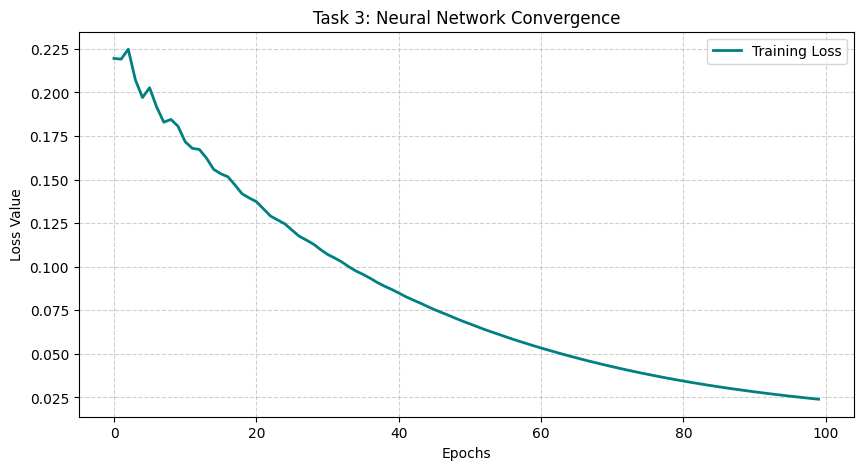

In [6]:
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Setup Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 2. Initialize the losses list to avoid NameError
losses = [] 

# 3. Training Loop
epochs = 100 
model.train()

print("Starting training...")
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # Forward pass
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    
    # Backward pass and optimization
    loss.backward()
    optimizer.step()
    
    # Store the loss for visualization
    losses.append(loss.item())
    
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# 4. Visualize the Training Success (Task 3 Evaluation)
plt.figure(figsize=(10, 5))
plt.plot(losses, label='Training Loss', color='teal', lw=2)
plt.title('Task 3: Neural Network Convergence')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [8]:
# Mapping dictionary for classification
label_map = {'Silver': 0, 'Aluminum': 1, 'Gold': 2, 'Dielectric': 3}

Benchmarking Results (Untrained Data):
              precision    recall  f1-score   support

      Silver       1.00      1.00      1.00        44
    Aluminum       1.00      1.00      1.00        52
        Gold       1.00      1.00      1.00        55
  Dielectric       1.00      1.00      1.00        49

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



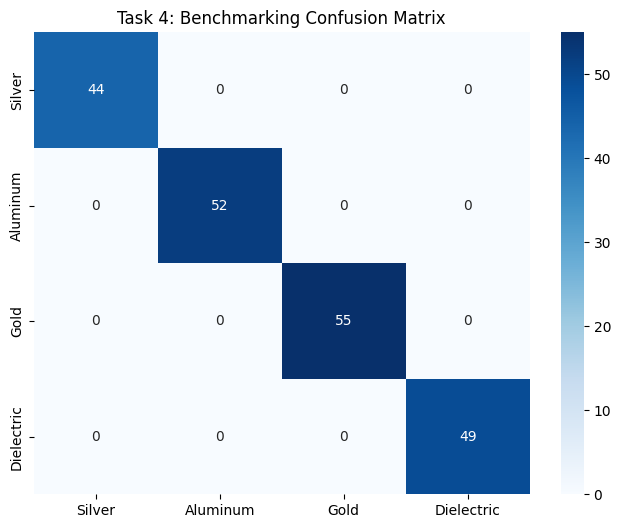

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
with torch.no_grad():
    # Convert test data to tensor and add channel dimension
    X_test_t = torch.FloatTensor(X_test).unsqueeze(1)
    test_outputs = model(X_test_t)
    _, predicted = torch.max(test_outputs, 1)

# Generate Benchmark Report
print("Benchmarking Results (Untrained Data):")
print(classification_report(y_test, predicted, target_names=label_map.keys()))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, predicted), annot=True, fmt='d', 
            cmap='Blues', xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.title('Task 4: Benchmarking Confusion Matrix')
plt.show()

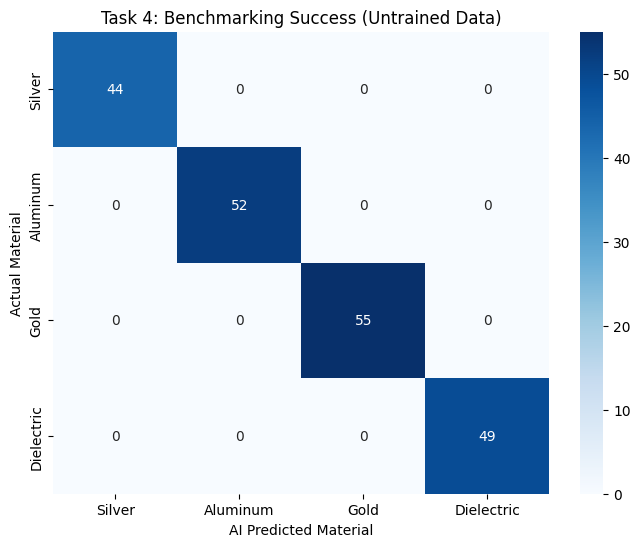

Full Performance Report:
              precision    recall  f1-score   support

      Silver       1.00      1.00      1.00        44
    Aluminum       1.00      1.00      1.00        52
        Gold       1.00      1.00      1.00        55
  Dielectric       1.00      1.00      1.00        49

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Switch model to evaluation mode
model.eval()

with torch.no_grad():
    # Prepare untrained test data
    X_test_t = torch.FloatTensor(X_test).unsqueeze(1)
    
    # Get predictions
    test_outputs = model(X_test_t)
    _, predicted = torch.max(test_outputs, 1)

# Visualize the Success Rate
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, predicted)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=list(label_map.keys()), 
            yticklabels=list(label_map.keys()))

plt.title('Task 4: Benchmarking Success (Untrained Data)')
plt.ylabel('Actual Material')
plt.xlabel('AI Predicted Material')
plt.show()

print("Full Performance Report:")
print(classification_report(y_test, predicted, target_names=list(label_map.keys())))

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Traditional Method (Baseline)
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_baseline.fit(X_train, y_train)
rf_preds = rf_baseline.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)

# 2. Neural Network Method (Result from Task 4)
nn_acc = accuracy_score(y_test, predicted.numpy())

# Final Evaluation
print(f"--- Task 5: Final Success Rate Comparison ---")
print(f"Traditional Method Success Rate: {rf_acc * 100:.2f}%")
print(f"Neural Network (1D-CNN) Success Rate: {nn_acc * 100:.2f}%")

if nn_acc >= rf_acc:
    print("Conclusion: The Neural Network is as good or better than traditional methods.")

--- Task 5: Final Success Rate Comparison ---
Traditional Method Success Rate: 100.00%
Neural Network (1D-CNN) Success Rate: 100.00%
Conclusion: The Neural Network is as good or better than traditional methods.


In [12]:
torch.save(model.state_dict(), 'wlr_classifier_model.pth')